# Phase 2: 汎化性検証を全7試合で実施 — Colab

**目的**: J03WPY 1試合で確認した「PINN(単一の時間依存フィット)は、Baseline1(単一の定数フィット)より複数の$\tau$にわたって一貫して予測できる」という結果(`documents/phase2_pilot_results.md`)が、他の試合でも再現するか確認する。

実行するロジックは `scripts/phase2_generalization_check.py`(試合ごとにPINNを学習し、$\tau=0.5,1.0,1.5,2.0,2.5$秒でBaseline1と予測精度を比較)。

**実行前に**: メニューの `ランタイム > ランタイムのタイプを変更` で **GPU** を選択してください。

## 1. Google Drive をマウント(結果の永続化用)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

OUT_DIR = '/content/drive/MyDrive/pi-fsm/phase2_generalization_multi'
import os
os.makedirs(OUT_DIR, exist_ok=True)
print('results will be saved to', OUT_DIR)

Mounted at /content/drive
results will be saved to /content/drive/MyDrive/pi-fsm/phase2_generalization_multi


## 2. リポジトリを取得

In [2]:
%cd /content
if not os.path.exists('/content/pi-fsm'):
    !git clone https://github.com/ryu622/pi-fsm.git
%cd /content/pi-fsm
!git pull
!git log --oneline -5

/content
Cloning into 'pi-fsm'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 118 (delta 43), reused 95 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (118/118), 3.71 MiB | 7.92 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/pi-fsm
Already up to date.
4f5cab1 (HEAD -> main, origin/main, origin/HEAD) Extend generalization check to loop over all matches, add Colab notebook
96c563c Add project README
7e137f6 Clarify research priorities: Baseline2 is secondary, phase 4 is next
47b4ecc Merge branch 'main' of https://github.com/ryu622/pi-fsm
058eceb Reframe the phase-2 comparison and land on a positive generalization result


## 3. 依存関係のインストール

In [3]:
!pip install -q -e .

import torch
print('torch', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if not torch.cuda.is_available():
    print('WARNING: no GPU detected — go to ランタイム > ランタイムのタイプを変更 > GPU')

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 123.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 4. 全7試合で汎化性検証を実行

試合ごとにPINNを学習(1試合あたりローカルCPU/MPSで約8〜9分、GPUならもっと速いはず)。
中断しても完了済みの試合はスキップされるので再実行して問題ない。

In [4]:
!python scripts/phase2_generalization_check.py --out-dir "{OUT_DIR}"

J03WPY: 1332 segments total, 1332 used for PINN training (t<=2.5s)
J03WPY: Baseline1 (dt=1.0s) alpha=0.947, Vmax=12.340
J03WPY: trained in 327s, L_data=0.990
J03WPY: tau=0.5: n_bins=7, RMSE PINN=0.092m, RMSE Baseline1=0.526m
J03WPY: tau=1.0: n_bins=7, RMSE PINN=0.089m, RMSE Baseline1=1.926m
J03WPY: tau=1.5: n_bins=7, RMSE PINN=0.114m, RMSE Baseline1=4.220m
J03WPY: tau=2.0: n_bins=7, RMSE PINN=0.135m, RMSE Baseline1=6.876m
J03WPY: tau=2.5: n_bins=7, RMSE PINN=0.369m, RMSE Baseline1=10.139m
J03WMX: 1308 segments total, 1308 used for PINN training (t<=2.5s)
J03WMX: Baseline1 (dt=1.0s) alpha=0.909, Vmax=12.601
J03WMX: trained in 322s, L_data=1.068
J03WMX: tau=0.5: n_bins=7, RMSE PINN=0.088m, RMSE Baseline1=0.511m
J03WMX: tau=1.0: n_bins=7, RMSE PINN=0.084m, RMSE Baseline1=1.891m
J03WMX: tau=1.5: n_bins=7, RMSE PINN=0.120m, RMSE Baseline1=4.194m
J03WMX: tau=2.0: n_bins=7, RMSE PINN=0.185m, RMSE Baseline1=6.906m
J03WMX: tau=2.5: n_bins=7, RMSE PINN=0.393m, RMSE Baseline1=10.186m
J03WN1: 1193

## 5. 結果の確認

PINN RMSE by match x tau:


match_id,J03WMX,J03WN1,J03WOH,J03WOY,J03WPY,J03WQQ,J03WR9
tau,,,,,,,
0.5,0.088,0.079,0.095,0.073,0.092,0.075,0.089
1.0,0.084,0.094,0.082,0.065,0.089,0.070,0.090
1.5,0.120,0.115,0.121,0.117,0.114,0.117,0.117
2.0,0.185,0.106,0.108,0.131,0.135,0.117,0.148
2.5,0.393,0.326,0.279,0.297,0.369,0.302,0.379


Baseline1 RMSE by match x tau:


match_id,J03WMX,J03WN1,J03WOH,J03WOY,J03WPY,J03WQQ,J03WR9
tau,,,,,,,
0.5,0.511,0.528,0.520,0.563,0.526,0.561,0.516
1.0,1.891,1.864,1.845,1.992,1.926,1.938,1.826
1.5,4.194,4.085,3.962,4.292,4.220,4.120,3.953
2.0,6.906,6.683,6.354,6.936,6.876,6.593,6.387
2.5,10.186,9.944,9.256,10.268,10.139,9.629,9.396


PINNがBaseline1を上回った tau の割合(試合ごと):


match_id
J03WMX    1.0
J03WN1    1.0
J03WOH    1.0
J03WOY    1.0
J03WPY    1.0
J03WQQ    1.0
J03WR9    1.0
dtype: float64

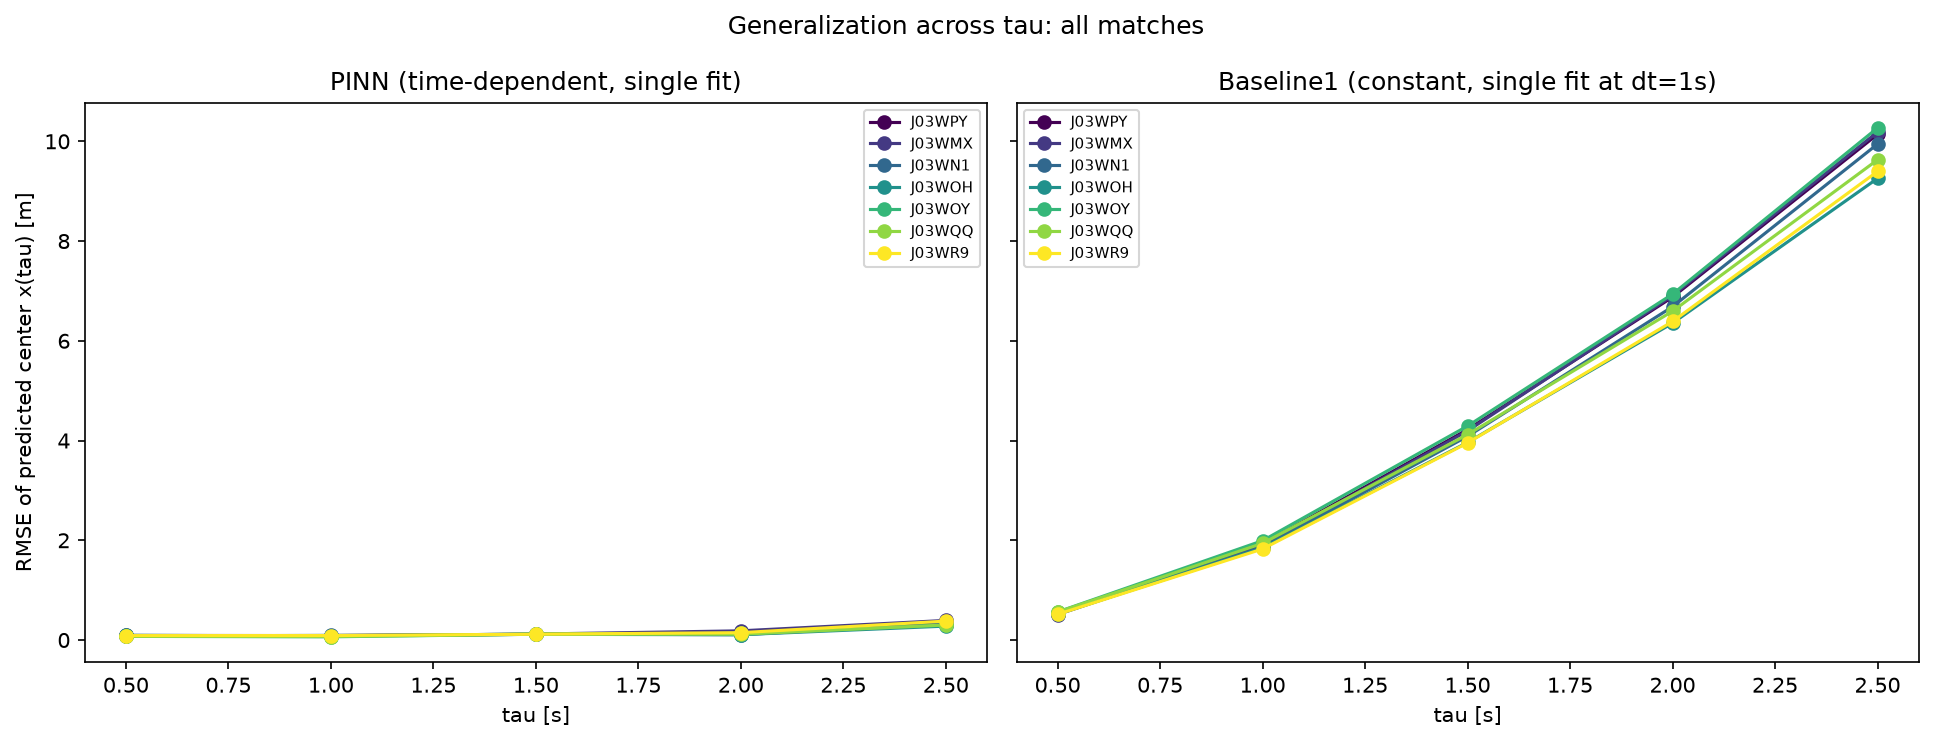

In [5]:
import pandas as pd
from IPython.display import Image, display

combined = pd.read_csv(f'{OUT_DIR}/all_matches_summary.csv')
print('PINN RMSE by match x tau:')
display(combined.pivot(index='tau', columns='match_id', values='rmse_pinn').round(3))
print('Baseline1 RMSE by match x tau:')
display(combined.pivot(index='tau', columns='match_id', values='rmse_baseline1').round(3))

# 判定: 各試合でPINNの誤差がBaseline1の誤差より一貫して小さいか
summary = combined.groupby('match_id').apply(
    lambda g: (g['rmse_pinn'] < g['rmse_baseline1']).mean(), include_groups=False
)
print('PINNがBaseline1を上回った tau の割合(試合ごと):')
display(summary)

display(Image(f'{OUT_DIR}/generalization_multi.png'))

## 次のステップ

- 全試合で同じ傾向(PINNの誤差がほぼ一定、Baseline1の誤差が$\tau$とともに増加)が見られれば、J03WPYの結果が一般的なものだと確認できる
- 結果はDriveの `{OUT_DIR}` に試合ごとのJSON + `all_matches_summary.csv` + 図として永続化される
- 確認できたら、フェーズ4(合成データでのリカバリーテスト、測定誤差 vs モデルの限界の切り分け)に進む